In [3]:
import pandas as pd

df = pd.read_csv(r"c:\Users\Portátil\ProjecteData\Equip_23\Data\16 March\Bank_Marketing_Cleaned_16_march.csv")
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,...,month,duration,campaign,pdays,previous,poutcome,deposit,year,date,weekday
0,1,59,admin.,married,secondary,no,2343,yes,no,unknown,...,may,1042,1,-1,0,unknown,yes,2008,2008-05-05,Monday
1,2,56,admin.,married,secondary,no,45,no,no,unknown,...,may,1467,1,-1,0,unknown,yes,2008,2008-05-05,Monday
2,3,41,technician,married,secondary,no,1270,yes,no,unknown,...,may,1389,1,-1,0,unknown,yes,2008,2008-05-05,Monday
3,4,55,services,married,secondary,no,2476,yes,no,unknown,...,may,579,1,-1,0,unknown,yes,2008,2008-05-05,Monday
4,5,54,admin.,married,tertiary,no,184,no,no,unknown,...,may,673,2,-1,0,unknown,yes,2008,2008-05-05,Monday


In [4]:
df.columns.tolist()

['id',
 'age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit',
 'year',
 'date',
 'weekday']

In [5]:
# ordenamos columnas
df = df.loc[:, [
    'id', 'age', 'job', 'marital', 'education', 'default', 'balance',
    'housing', 'loan', 'contact', 'day', 'month',
    'weekday','date','year',  # << aquí les noves columnes
    'duration', 'campaign', 'pdays', 'previous', 'poutcome',
    'deposit'
]]

In [6]:
import pandas as pd

df['conversion'] = (df['deposit'] == 'yes').astype(int)

# Conversió per dia
summary = df.groupby('weekday').agg(
    total_calls=('id', 'count'),
    deposits_yes=('conversion', 'sum'),
    conversion_rate=('conversion', 'mean')
).reset_index()


orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
#ordenar días de la semana
summary = summary.set_index('weekday').reindex(orden_dias).reset_index()
# adaptar%
summary['conversion_rate'] = (summary['conversion_rate'] * 100).round(2)


print(summary)


     weekday  total_calls  deposits_yes  conversion_rate
0     Monday          861           812            94.31
1    Tuesday         1410           949            67.30
2  Wednesday         2126          1071            50.38
3   Thursday         2390          1205            50.42
4     Friday         2259          1010            44.71
5   Saturday         1303           164            12.59
6     Sunday          813            78             9.59


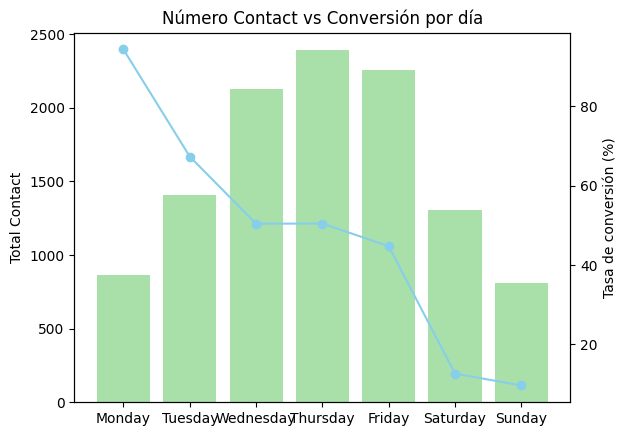

In [7]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

ax1.bar(summary['weekday'], summary['total_calls'], color="#A9E0A9", label='Llamadas')
ax1.set_ylabel('Total Contact')

ax2 = ax1.twinx()
ax2.plot(summary['weekday'], summary['conversion_rate'], color='Skyblue', marker='o', label='Conversión (%)')
ax2.set_ylabel('Tasa de conversión (%)')

plt.title('Número Contact vs Conversión por día')
# 🔹 Reducir tamaño de las letras del eje X
plt.xticks(rotation=45, fontsize=8)
 #Guardar la figura com a PNG (abans de show)
plt.savefig("barras_contacto_conversion.png", dpi=300, bbox_inches="tight")
plt.show()

Qué permite concluir este análisis:
Podemos identificar qué día convierte mejor.--> lunes
 - Si se quiere maximizar resultados, esos son los días clave.
Podemos ver si los días con más llamadas son realmente los más efectivos.--> jueves más llamadas pero es cuarto día de conversión
 - Esto demuestra que más volumen no implica mejor rendimiento.

Podemos detectar patrones semanales (por ejemplo, fines de semana mejores o peores).--> inicio de semana es mejor. En concreto lunes.
 - Sábado y domingo tienen conversiones muy bajas (12.59% y 9.59%).
 
Podemos tomar decisiones estratégicas como:
“Llamar más los días con mejor conversión”---> llamar más el lunes y martes
“Reducir esfuerzo en días con bajo rendimiento”-->vfin de semana es poco productivo
“Ajustar el tipo de contacto según el día”

Recomendación operativa:
 - Reforzar el equipo los lunes y martes.
 - Reducir personal los fines de semana.
 - Optimizar contact según el día.

 Posible análisis adicional
 - Analizar por franja horaria dentro de cada día
 - Ver si ciertos segmentos de clientes responden mejor en ciertos días
 - Comparar con semanas anteriores o meses distintos

### HEATMAP: conversión por día y tipo de contacto

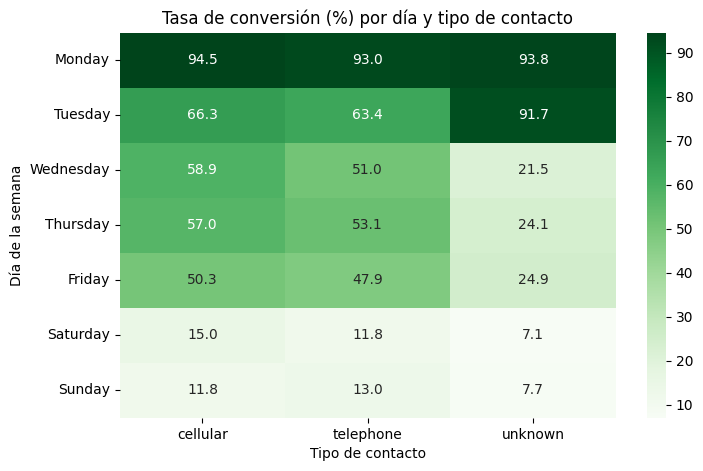

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Variable binaria de conversión
df['conversion'] = (df['deposit'] == 'yes').astype(int)

# 2. Orden correcto de días
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# 3. Agrupación por día y tipo de contacto
summary_contact = df.groupby(['weekday', 'contact']).agg(
    conversion_rate=('conversion', 'mean')
).reset_index()

# 4. Convertir a porcentaje
summary_contact['conversion_rate'] = summary_contact['conversion_rate'] * 100

# 5. Pivotar para crear la matriz del heatmap
heatmap_data = summary_contact.pivot(index='weekday', columns='contact', values='conversion_rate')

# 6. Ordenar días
heatmap_data = heatmap_data.reindex(orden_dias)

# 7. Dibujar heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Greens")
plt.title("Tasa de conversión (%) por día y tipo de contacto")
plt.ylabel("Día de la semana")
plt.xlabel("Tipo de contacto")
plt.show()

### Tasa de conversión mediana

In [9]:
df['Semana'] = df['weekday'].isin(['Monday', 'Tuesday','Wednesday','Thursday','Friday'])
Ratio_conversio=df.groupby('Semana')['conversion'].mean().round(4)*100
Ratio_conversio.round(4).astype(str)+'%'

Semana
False    11.44%
True     55.79%
Name: conversion, dtype: object

### Conclusion:
  - La conversión entre semana (56%) es cinco veces superior a la del fin de semana (11%).
  - Son medians de conversión.
  - La estrategia óptima es concentrar recursos en días laborables y reducir esfuerzos en sábado y domingo.

# Modelo de regresión logística

Optimization terminated successfully.
         Current function value: 0.565804
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         deposit_binary   No. Observations:                11162
Model:                          Logit   Df Residuals:                    11153
Method:                           MLE   Df Model:                            8
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.1821
Time:                        11:56:13   Log-Likelihood:                -6315.5
converged:                       True   LL-Null:                       -7721.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0219      0.045      0.488      0.625      -0.066       0.110
weekday_

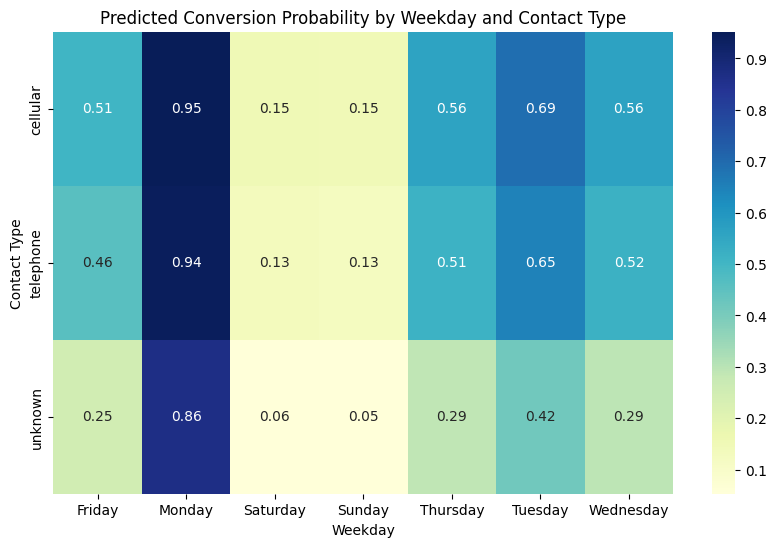

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

df = df.dropna(subset=['deposit', 'weekday', 'contact'])

df['deposit_binary'] = df['deposit'].map({'yes': 1, 'no': 0}).astype(float)

df_encoded = pd.get_dummies(df[['weekday','contact']], drop_first=True)
X = df_encoded.astype(float)  # ensure all numeric
y = df['deposit_binary']

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

df['pred_prob'] = result.predict(X)

prob_summary = df.groupby(['weekday', 'contact'])['pred_prob'].mean().reset_index()


pivot_table = prob_summary.pivot(index='contact', columns='weekday', values='pred_prob')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Predicted Conversion Probability by Weekday and Contact Type")
plt.ylabel("Contact Type")
plt.xlabel("Weekday")
plt.show()